In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_races = pd.read_csv("../data/raw/races.csv")
df_weather = pd.read_csv("../data/raw/weather.csv")
df_quali = pd.read_csv("../data/raw/qualifying.csv")

print("Races:", df_races.shape)
print("Weather:", df_weather.shape)
print("Qualifying:", df_quali.shape)

df_races.head()

Races: (1926, 10)
Weather: (96, 6)
Qualifying: (1927, 8)


,season,round,circuit,driver,team,grid,position,points,status,podium
0,2022,1,Bahrain Grand Prix,LEC,Ferrari,1.0,1.0,26.0,Finished,1
1,2022,1,Bahrain Grand Prix,SAI,Ferrari,3.0,2.0,18.0,Finished,1
2,2022,1,Bahrain Grand Prix,HAM,Mercedes,5.0,3.0,15.0,Finished,1
3,2022,1,Bahrain Grand Prix,RUS,Mercedes,9.0,4.0,12.0,Finished,0
4,2022,1,Bahrain Grand Prix,MAG,Haas F1 Team,7.0,5.0,10.0,Finished,0


In [2]:
print("=== RACES ===")
print(df_races.dtypes)
print(df_races.isnull().sum())
print()
print("=== QUALIFYING ===")
print(df_quali.dtypes)
print(df_quali.isnull().sum())
print()
print("=== WEATHER ===")
print(df_weather.dtypes)
print(df_weather.isnull().sum())

=== RACES ===
season        int64
round         int64
circuit      object
driver       object
team         object
grid        float64
position    float64
points      float64
status       object
podium        int64
dtype: object
season      0
round       0
circuit     0
driver      0
team        0
grid        2
position    2
points      0
status      0
podium      0
dtype: int64

=== QUALIFYING ===
season               int64
round                int64
driver              object
grid_position      float64
best_quali_time    float64
gap_to_pole        float64
made_q3              int64
made_q2              int64
dtype: object
season              0
round               0
driver              0
grid_position      48
best_quali_time    66
gap_to_pole        66
made_q3             0
made_q2             0
dtype: int64

=== WEATHER ===
season            int64
round             int64
avg_temp        float64
avg_humidity    float64
avg_wind        float64
rainfall          int64
dtype: object
seaso

In [3]:
print("Podium distribution:")
print(df_races["podium"].value_counts())
print(f"\nPodium rate: {df_races['podium'].mean():.2%}")
print(f"Total podiums: {df_races['podium'].sum()} (expected ~{len(df_races)//20 * 3})")

# check who's getting podiums
print("\nTop 10 drivers by podium count:")
print(df_races.groupby("driver")["podium"].sum().sort_values(ascending=False).head(10))

Podium distribution:
podium
0    1638
1     288
Name: count, dtype: int64

Podium rate: 14.95%
Total podiums: 288 (expected ~288)

Top 10 drivers by podium count:
driver
VER    67
NOR    40
LEC    39
PIA    28
RUS    25
PER    24
SAI    23
HAM    21
ALO     8
ANT     7
Name: podium, dtype: int64


In [4]:
# drop DNS/DNF rows with no position or grid
df_races = df_races.dropna(subset=["position", "grid"])
print(f"Races after dropping nulls: {len(df_races)}")

# merge races + qualifying
df = df_races.merge(
    df_quali[["season","round","driver","best_quali_time","gap_to_pole"]],
    on=["season","round","driver"],
    how="left"
)

# merge weather
df = df.merge(df_weather, on=["season","round"], how="left")

print(f"Merged shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Races after dropping nulls: 1924
Merged shape: (1924, 16)
Columns: ['season', 'round', 'circuit', 'driver', 'team', 'grid', 'position', 'points', 'status', 'podium', 'best_quali_time', 'gap_to_pole', 'avg_temp', 'avg_humidity', 'avg_wind', 'rainfall']


,season,round,circuit,driver,team,grid,position,points,status,podium,best_quali_time,gap_to_pole,avg_temp,avg_humidity,avg_wind,rainfall
0,2022,1,Bahrain Grand Prix,LEC,Ferrari,1.0,1.0,26.0,Finished,1,90.558,0.000,23.62,29.49,0.3,0
1,2022,1,Bahrain Grand Prix,SAI,Ferrari,3.0,2.0,18.0,Finished,1,90.687,0.129,23.62,29.49,0.3,0
2,2022,1,Bahrain Grand Prix,HAM,Mercedes,5.0,3.0,15.0,Finished,1,91.238,0.680,23.62,29.49,0.3,0
3,2022,1,Bahrain Grand Prix,RUS,Mercedes,9.0,4.0,12.0,Finished,0,92.216,1.658,23.62,29.49,0.3,0
4,2022,1,Bahrain Grand Prix,MAG,Haas F1 Team,7.0,5.0,10.0,Finished,0,91.808,1.250,23.62,29.49,0.3,0


In [5]:
# fix grid and position to int
df["grid"] = df["grid"].astype(int)
df["position"] = pd.to_numeric(df["position"], errors="coerce").astype("Int64")

df = df.dropna(subset=["gap_to_pole", "best_quali_time"])
print(f"Rows after dropping missing quali: {len(df)}")

print("Nulls remaining:")
print(df.isnull().sum())
print(f"\ngrid dtype: {df['grid'].dtype}")
print(f"position dtype: {df['position'].dtype}")

Rows after dropping missing quali: 1858
Nulls remaining:
season             0
round              0
circuit            0
driver             0
team               0
grid               0
position           0
points             0
status             0
podium             0
best_quali_time    0
gap_to_pole        0
avg_temp           0
avg_humidity       0
avg_wind           0
rainfall           0
dtype: int64

grid dtype: int64
position dtype: Int64


In [6]:
# sort by time — non-negotiable for rolling features
df = df.sort_values(["season", "round"]).reset_index(drop=True)

# --- driver rolling form (last 5 races, excluding current) ---
# .shift(1) ensures we never leak current race result into features
df["rolling_podium_rate"] = (
    df.groupby("driver")["podium"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df["rolling_points"] = (
    df.groupby("driver")["points"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# --- team rolling form (last 5 races) ---
df["team_rolling_points"] = (
    df.groupby("team")["points"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# --- circuit-specific podium rate per driver ---
df["circuit_podium_rate"] = (
    df.groupby(["driver", "circuit"])["podium"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# fill nulls for first appearances (no history yet)
df["rolling_podium_rate"] = df["rolling_podium_rate"].fillna(0)
df["rolling_points"] = df["rolling_points"].fillna(0)
df["team_rolling_points"] = df["team_rolling_points"].fillna(0)
df["circuit_podium_rate"] = df["circuit_podium_rate"].fillna(0)

print("Rolling features added:")
print(df[["driver","season","round","rolling_podium_rate",
          "rolling_points","team_rolling_points",
          "circuit_podium_rate"]].head(20))

Rolling features added:
   driver  season  round  rolling_podium_rate  rolling_points  \
0     LEC    2022      1                  0.0             0.0   
1     SAI    2022      1                  0.0             0.0   
2     HAM    2022      1                  0.0             0.0   
3     RUS    2022      1                  0.0             0.0   
4     MAG    2022      1                  0.0             0.0   
5     BOT    2022      1                  0.0             0.0   
6     OCO    2022      1                  0.0             0.0   
7     TSU    2022      1                  0.0             0.0   
8     ALO    2022      1                  0.0             0.0   
9     ZHO    2022      1                  0.0             0.0   
10    MSC    2022      1                  0.0             0.0   
11    STR    2022      1                  0.0             0.0   
12    ALB    2022      1                  0.0             0.0   
13    RIC    2022      1                  0.0             0.0   
1

In [7]:
# check a driver we know well across a few races
ver = df[df["driver"]=="VER"][
    ["season","round","circuit","podium","points",
     "rolling_podium_rate","rolling_points",
     "team_rolling_points","circuit_podium_rate"]
].head(15)
print(ver.to_string())

     season  round                    circuit  podium  points  rolling_podium_rate  rolling_points  team_rolling_points  circuit_podium_rate
18     2022      1         Bahrain Grand Prix       0     0.0             0.000000        0.000000                  0.0                  0.0
20     2022      2   Saudi Arabian Grand Prix       1    25.0             0.000000        0.000000                  0.0                  0.0
54     2022      3      Australian Grand Prix       0     0.0             0.500000       12.500000                 11.0                  0.0
57     2022      4  Emilia Romagna Grand Prix       1    26.0             0.333333        8.333333                 11.0                  0.0
76     2022      5           Miami Grand Prix       1    26.0             0.500000       12.750000                 14.8                  0.0
95     2022      6         Spanish Grand Prix       1    25.0             0.600000       15.400000                 16.4                  0.0
117    2022  

C:\Users\knigh\AppData\Local\Temp\ipykernel_11224\4016621140.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([


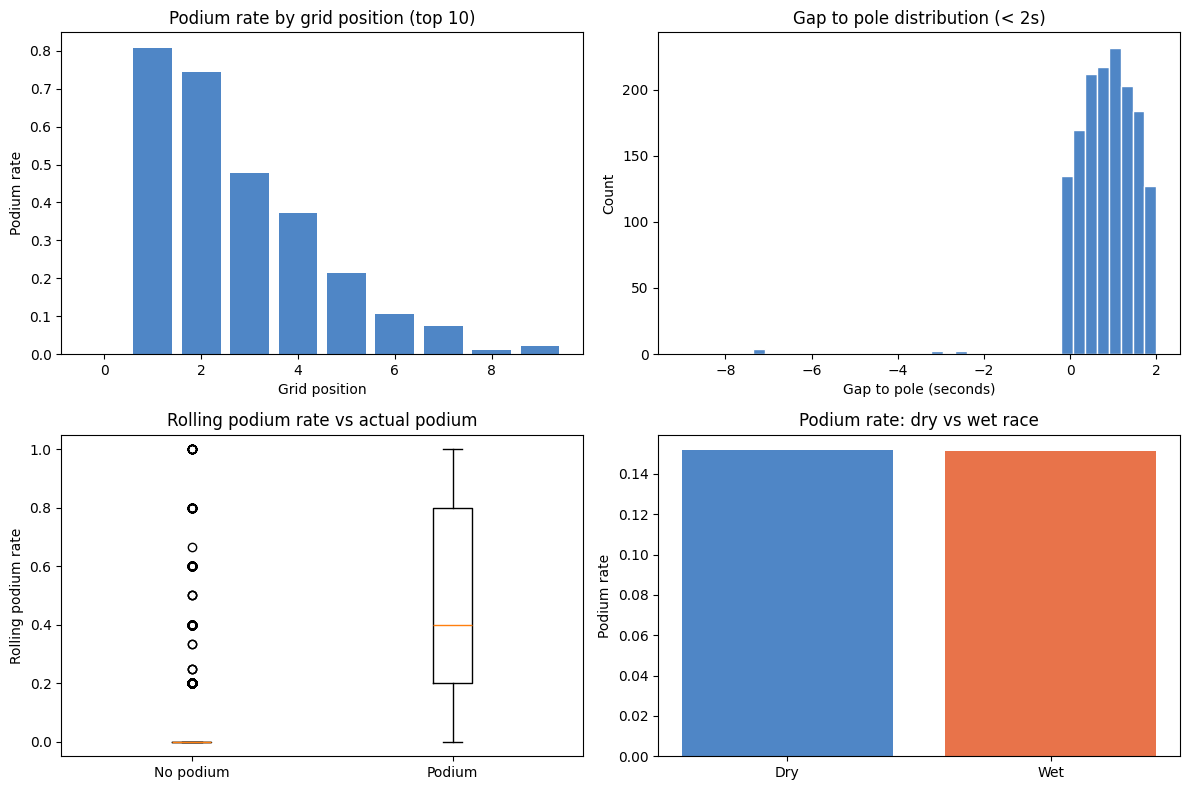

Saved to notebooks/feature_plots.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# podium rate by grid position
grid_podium = df.groupby("grid")["podium"].mean()
axes[0,0].bar(grid_podium.index[:10], grid_podium.values[:10], color="#4F86C6")
axes[0,0].set_title("Podium rate by grid position (top 10)")
axes[0,0].set_xlabel("Grid position")
axes[0,0].set_ylabel("Podium rate")

# gap to pole distribution
axes[0,1].hist(df[df["gap_to_pole"]<2]["gap_to_pole"], 
               bins=40, color="#4F86C6", edgecolor="white")
axes[0,1].set_title("Gap to pole distribution (< 2s)")
axes[0,1].set_xlabel("Gap to pole (seconds)")
axes[0,1].set_ylabel("Count")

# rolling podium rate vs actual podium
axes[1,0].boxplot([
    df[df["podium"]==0]["rolling_podium_rate"],
    df[df["podium"]==1]["rolling_podium_rate"]
], labels=["No podium","Podium"])
axes[1,0].set_title("Rolling podium rate vs actual podium")
axes[1,0].set_ylabel("Rolling podium rate")

# rainfall effect on podiums
rain_podium = df.groupby("rainfall")["podium"].mean()
axes[1,1].bar(["Dry","Wet"], rain_podium.values, color=["#4F86C6","#E8734A"])
axes[1,1].set_title("Podium rate: dry vs wet race")
axes[1,1].set_ylabel("Podium rate")

plt.tight_layout()
plt.savefig("../notebooks/feature_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to notebooks/feature_plots.png")

In [9]:
print("Gap to pole stats before fix:")
print(df["gap_to_pole"].describe())
print(f"\nNegative values: {(df['gap_to_pole'] < 0).sum()}")

# gap to pole should always be >= 0
# negative values mean the reference pole time was wrong — take absolute value
df["gap_to_pole"] = df["gap_to_pole"].abs()

# also clip extreme outliers (> 5s gap is likely a data error)
df["gap_to_pole"] = df["gap_to_pole"].clip(upper=5.0)

print("\nGap to pole stats after fix:")
print(df["gap_to_pole"].describe())

Gap to pole stats before fix:
count    1858.000000
mean        1.490479
std         2.731002
min        -9.009000
25%         0.521500
50%         1.095000
75%         1.753000
max        62.297000
Name: gap_to_pole, dtype: float64

Negative values: 28

Gap to pole stats after fix:
count    1858.000000
mean        1.361826
std         1.164817
min         0.000000
25%         0.546500
50%         1.126500
75%         1.789500
max         5.000000
Name: gap_to_pole, dtype: float64


C:\Users\knigh\AppData\Local\Temp\ipykernel_11224\4016621140.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([


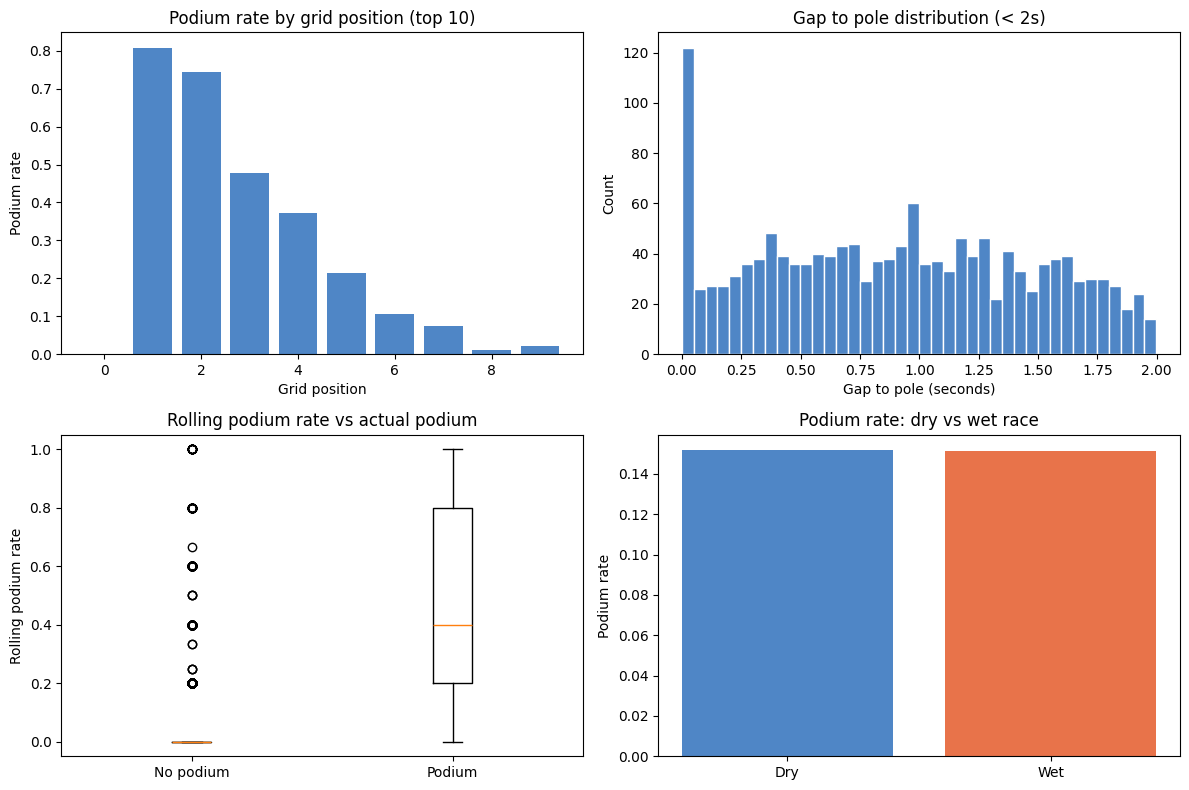

Saved to notebooks/feature_plots.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# podium rate by grid position
grid_podium = df.groupby("grid")["podium"].mean()
axes[0,0].bar(grid_podium.index[:10], grid_podium.values[:10], color="#4F86C6")
axes[0,0].set_title("Podium rate by grid position (top 10)")
axes[0,0].set_xlabel("Grid position")
axes[0,0].set_ylabel("Podium rate")

# gap to pole distribution
axes[0,1].hist(df[df["gap_to_pole"]<2]["gap_to_pole"], 
               bins=40, color="#4F86C6", edgecolor="white")
axes[0,1].set_title("Gap to pole distribution (< 2s)")
axes[0,1].set_xlabel("Gap to pole (seconds)")
axes[0,1].set_ylabel("Count")

# rolling podium rate vs actual podium
axes[1,0].boxplot([
    df[df["podium"]==0]["rolling_podium_rate"],
    df[df["podium"]==1]["rolling_podium_rate"]
], labels=["No podium","Podium"])
axes[1,0].set_title("Rolling podium rate vs actual podium")
axes[1,0].set_ylabel("Rolling podium rate")

# rainfall effect on podiums
rain_podium = df.groupby("rainfall")["podium"].mean()
axes[1,1].bar(["Dry","Wet"], rain_podium.values, color=["#4F86C6","#E8734A"])
axes[1,1].set_title("Podium rate: dry vs wet race")
axes[1,1].set_ylabel("Podium rate")

plt.tight_layout()
plt.savefig("../notebooks/feature_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to notebooks/feature_plots.png")

In [11]:
feature_cols = [
    "grid", "gap_to_pole", "best_quali_time",
    "rolling_podium_rate", "rolling_points",
    "team_rolling_points", "circuit_podium_rate",
    "avg_temp", "avg_humidity", "avg_wind", "rainfall",
    "podium"
]

meta_cols = ["season", "round", "circuit", "driver", "team"]
df_final = df[meta_cols + feature_cols].copy()

print("Final null check:")
print(df_final.isnull().sum())
print(f"\nFinal shape: {df_final.shape}")
print(f"\nPodium distribution:")
print(df_final["podium"].value_counts())

df_final.to_csv("../data/processed/features.csv", index=False)
print("\nSaved to data/processed/features.csv")

Final null check:
season                 0
round                  0
circuit                0
driver                 0
team                   0
grid                   0
gap_to_pole            0
best_quali_time        0
rolling_podium_rate    0
rolling_points         0
team_rolling_points    0
circuit_podium_rate    0
avg_temp               0
avg_humidity           0
avg_wind               0
rainfall               0
podium                 0
dtype: int64

Final shape: (1858, 17)

Podium distribution:
podium
0    1576
1     282
Name: count, dtype: int64

Saved to data/processed/features.csv
